# Prueba Modelo A
Entrenamiento completo con métricas de evaluación

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
from tqdm import tqdm # para mostrar barras de progreso
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from modeloA import UNet

## Crear modelo

In [3]:
# Crear modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, num_classes=2, base_ch=32).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Modelo U-Net Base creado")
print(f"   Device: {device}")
print(f"   Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

Modelo U-Net Base creado
   Device: cuda
   Parámetros totales: 7,766,018
   Parámetros entrenables: 7,766,018


## Cargar datos de entrenamiento
(Data preprocesada)

In [4]:
import pickle

# Cargar el archivo
with open('data_minimal.pkl', 'rb') as f:
    data = pickle.load(f)

In [5]:
from dataset_form import train_transform, val_transform, SimpleDataset
from torch.utils.data import DataLoader, WeightedRandomSampler
import torch
import numpy as np

train_tiles = data['train']
val_tiles = data['val']
test_tiles = data['test']
annotations_dict = data['annotations']

# Reconstruir datasets
train_dataset = SimpleDataset(train_tiles, '../train/', annotations_dict, train_transform)
val_dataset = SimpleDataset(val_tiles, '../train/', annotations_dict, val_transform)
test_dataset = SimpleDataset(test_tiles, '../train/', annotations_dict, val_transform)

# Calcular conteo de píxeles por clase (puede tardar)
def compute_class_pixel_counts(dataset, max_samples=None):
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)
    counts = np.zeros(2, dtype=np.int64)
    image_has_pos = []
    for i, batch in enumerate(loader):
        mask = batch[1] if len(batch) > 1 else None
        if mask is None:
            image_has_pos.append(False)
            continue
        m = mask[0].numpy()
        m_valid = m[m != 255]
        if m_valid.size > 0:
            vals, cts = np.unique(m_valid, return_counts=True)
            for v, c in zip(vals, cts):
                if int(v) in [0, 1]:
                    counts[int(v)] += int(c)
        image_has_pos.append((m == 1).sum() > 0)
        if max_samples and (i + 1) >= max_samples:
            break
    return counts, np.array(image_has_pos)

print('Calculando conteo de píxeles (esto puede tomar un momento)')
counts, image_has_pos = compute_class_pixel_counts(train_dataset)
print('Pixel counts (train):', counts)

# Pesos por clase inverso-proporcionales
class_weights = torch.tensor(counts, dtype=torch.float32)
class_weights = class_weights.sum() / (class_weights + 1e-9)
print('Class weights (to use for Focal/Dice):', class_weights)

# WeightedRandomSampler: 2x para imágenes con vasos
num_pos = int(image_has_pos.sum())
num_neg = int(len(image_has_pos) - num_pos)
sampler = None
if num_pos == 0:
    print('No se encontraron imágenes con la clase positiva en el set de entrenamiento. No se aplicará sampler balanceado.')
else:
    sample_weights = np.where(image_has_pos, 2.0, 1.0).astype(np.float32)
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    print(f'WeightedRandomSampler creado (2x para positivos): {num_pos} positivas, {num_neg} negativas')

# DataLoaders optimizados
pin_mem = (device.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=8, sampler=sampler, num_workers=4, pin_memory=pin_mem, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=pin_mem, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=pin_mem, drop_last=False)

Calculando conteo de píxeles (esto puede tomar un momento)
Pixel counts (train): [315976448   3547531]
Class weights (to use for Focal/Dice): tensor([ 1.0112, 90.0694])
WeightedRandomSampler creado (2x para positivos): 1173 positivas, 3750 negativas
Pixel counts (train): [315976448   3547531]
Class weights (to use for Focal/Dice): tensor([ 1.0112, 90.0694])
WeightedRandomSampler creado (2x para positivos): 1173 positivas, 3750 negativas


## Funciones de pérdida y métricas

In [7]:
class DiceLoss(nn.Module):
    """Dice Loss para segmentación"""
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, predictions, targets):
        # predictions: [B, 2, H, W] (logits)
        # targets: [B, H, W] (0 o 1, ignorar 255)
        
        # Aplicar softmax
        predictions = F.softmax(predictions, dim=1)
        predictions = predictions[:, 1, :, :]  # Canal de vasos
        
        # Crear máscara válida (ignorar glomérulos = 255)
        valid_mask = (targets != 255).float()
        targets = (targets == 1).float()
        
        # Aplicar máscara válida
        predictions = predictions * valid_mask
        targets = targets * valid_mask
        
        # Calcular Dice
        intersection = (predictions * targets).sum()
        union = predictions.sum() + targets.sum()
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

In [ ]:
class CombinedLoss(nn.Module):
    """Combina Cross Entropy + Dice Loss.
    Puede recibir pesos por clase para CrossEntropy mediante ce_class_weWWight (torch.tensor)."""
    def __init__(self, ce_weight=0.5, dice_weight=0.5, ce_class_weight=None, ignore_index=255):
        super(CombinedLoss, self).__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        if ce_class_weight is not None:
            self.ce_loss = nn.CrossEntropyLoss(weight=ce_class_weight, ignore_index=ignore_index)
        else:
            self.ce_loss = nn.CrossEntropyLoss(ignore_index=ignore_index)
        self.dice_loss = DiceLoss()
    
    def forward(self, predictions, targets):
        ce = self.ce_loss(predictions, targets.long())
        dice = self.dice_loss(predictions, targets)
        return self.ce_weight * ce + self.dice_weight * dice

In [9]:
class FocalLoss(nn.Module):
    """Focal Loss para problemas multi-clase (usa logits)."""
    def __init__(self, gamma=2.0, weight=None, ignore_index=255, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.weight = weight
        self.ignore_index = ignore_index
        self.reduction = reduction
    
    def forward(self, inputs, targets):
        # inputs: [B, C, H, W], targets: [B, H, W] (integers)
        # Calcular CE por elemento sin reducción
        ce = F.cross_entropy(inputs, targets.long(), weight=self.weight, ignore_index=self.ignore_index, reduction='none')
        # Probabilidades del modelo
        probs = F.softmax(inputs, dim=1)
        # Obtener p_t (probabilidad de la clase verdadera)
        t = targets.clone()
        mask_ignore = (t == self.ignore_index)
        t[mask_ignore] = 0
        # probs permuted: [B,H,W,C] -> gather true class prob
        pt = probs.permute(0,2,3,1).gather(dim=3, index=t.unsqueeze(-1)).squeeze(-1)
        mod_factor = (1.0 - pt) ** self.gamma
        loss = mod_factor * ce
        # Excluir índices ignorados del agregado
        loss = loss[~mask_ignore]
        if self.reduction == 'mean':
            return loss.mean() if loss.numel() > 0 else torch.tensor(0., device=inputs.device)
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [10]:
def calculate_metrics(predictions, targets):
    """
    Calcula Precision, Recall, F1, Dice Score, IoU
    predictions: [B, 2, H, W] (logits)
    targets: [B, H, W] (0, 1, 255)
    """
    # Convertir a predicciones binarias
    preds = torch.argmax(predictions, dim=1)  # [B, H, W]
    
    # Filtrar valores válidos (ignorar 255)
    valid_mask = (targets != 255)
    preds_valid = preds[valid_mask].cpu().numpy()
    targets_valid = targets[valid_mask].cpu().numpy()
    
    # Calcular métricas con sklearn
    precision = precision_score(targets_valid, preds_valid, zero_division=0)
    recall = recall_score(targets_valid, preds_valid, zero_division=0)
    f1 = f1_score(targets_valid, preds_valid, zero_division=0)
    
    # Dice Score
    intersection = np.sum(preds_valid * targets_valid)
    union = np.sum(preds_valid) + np.sum(targets_valid)
    dice = (2. * intersection + 1e-7) / (union + 1e-7)
    
    # IoU
    intersection_iou = np.sum(preds_valid * targets_valid)
    union_iou = np.sum(preds_valid) + np.sum(targets_valid) - intersection_iou
    iou = (intersection_iou + 1e-7) / (union_iou + 1e-7)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'dice': dice,
        'iou': iou
    }

## **Entrenamiento**

In [18]:
# Hiperparámetros
EPOCHS = 200
LEARNING_RATE = 5e-5
PATIENCE = 30  # early stopping con doble paciencia del scheduler (scheduler patience=15)

In [19]:
# Optimizer y scheduler (AdamW + ReduceLROnPlateau más suave)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4, amsgrad=True)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.7, patience=15)

In [20]:
# Loss function
criterion = CombinedLoss(ce_weight=0.5, dice_weight=0.5)

In [21]:
# Historial de entrenamiento
history = {
    'train_loss': [],
    'val_loss': [],
    'val_precision': [],
    'val_recall': [],
    'val_f1': [],
    'val_dice': [],
    'val_iou': []
}

best_val_dice = 0.0
patience_counter = 0

In [22]:
# Configuración de verbose: cuando False solo se muestra una línea por época (resumen)
VERBOSE = False

print(f"Iniciando entrenamiento: epochs={EPOCHS}, lr={LEARNING_RATE}, opt=AdamW, device={device}") if VERBOSE else print(f"Entrenamiento: {EPOCHS} epochs — device: {device}")

# Configurar criterio: FocalLoss (gamma=2.0) + 2.0 * DiceLoss, con pesos por clase
try:
    ce_weights_device = class_weights.to(device)
except Exception:
    ce_weights_device = None

focal = FocalLoss(gamma=2.0, weight=ce_weights_device)
dice_loss = DiceLoss()

def criterion(outputs, masks):
    return focal(outputs, masks) + 2.0 * dice_loss(outputs, masks)

# Alternativa comentada: Focal + Dice
# focal = FocalLoss(gamma=2.0, weight=ce_weights_device)
# criterion = lambda outputs, masks: focal(outputs, masks) + 1.0 * DiceLoss()(outputs, masks)

# Usar AMP (mixed precision)
scaler = torch.cuda.amp.GradScaler()

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for images, masks, _ in train_bar:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item()
        # Mostrar loss en el postfix de tqdm (no prints)
        train_bar.set_postfix({'loss': f"{loss.item():.4f}"})
        del outputs, loss
        torch.cuda.empty_cache()

    avg_train_loss = train_loss / len(train_loader)
    history['train_loss'].append(avg_train_loss)
    
    # VALIDATION
    model.eval()
    val_loss = 0.0
    val_metrics = {'precision': [], 'recall': [], 'f1': [], 'dice': [], 'iou': []}
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]')
        for images, masks, _ in val_bar:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, masks)
            val_loss += loss.item()
            metrics = calculate_metrics(outputs, masks)
            for key in val_metrics:
                val_metrics[key].append(metrics[key])
            val_bar.set_postfix({'loss': f"{loss.item():.4f}", 'dice': f"{metrics['dice']:.4f}"})
            del outputs, loss, metrics
            torch.cuda.empty_cache()

    avg_val_loss = val_loss / len(val_loader)
    history['val_loss'].append(avg_val_loss)
    for key in val_metrics:
        avg_metric = np.mean(val_metrics[key])
        history[f'val_{key}'].append(avg_metric)
    avg_val_dice = np.mean(val_metrics['dice'])

    # Scheduler
    scheduler.step(avg_val_loss)

    # Resumen por época: una sola línea (más legible)
    summary_line = (f"Epoch {epoch+1}/{EPOCHS} | train_loss={avg_train_loss:.4f} | "
                    f"val_loss={avg_val_loss:.4f} | val_dice={avg_val_dice:.4f} | "
                    f"val_iou={np.mean(val_metrics['iou']):.4f}")
    print(summary_line)

    # Guardar mejor modelo (mensaje corto)
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'dice_score': best_val_dice,
        }, 'best_unet_base.pth')
        print(f"-> Mejor modelo guardado: Dice={best_val_dice:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1

    # Early stopping (mensaje corto)
    if patience_counter >= PATIENCE:
        print(f"Early stopping en época {epoch+1}")
        break

torch.cuda.empty_cache()
print(f"ENTRENAMIENTO COMPLETADO — Mejor Dice: {best_val_dice:.4f}")

/tmp/ipykernel_81373/2990397140.py:23: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Entrenamiento: 200 epochs — device: cuda


Epoch 1/200 [Train]:   0%|          | 0/615 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200 [Val]:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200 [Val]:   1%|          | 1/132 [00:00<01:03,  2.08it/s, loss=2.5521, dice=0.5872]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 1/200 [Val]:   1%|          | 1/132 [00:00<01:03,  2.08it/s, loss=1.9816, dice=0.0000]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please

Epoch 1/200 | train_loss=1.0708 | val_loss=1.8429 | val_dice=0.5432 | val_iou=0.4126
-> Mejor modelo guardado: Dice=0.5432


Epoch 2/200 [Train]:   0%|          | 0/615 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/200 [Val]:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/200 [Val]:   1%|          | 1/132 [00:00<01:04,  2.03it/s, loss=2.3600, dice=0.5749]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 2/200 [Val]:   1%|          | 1/132 [00:00<01:04,  2.03it/s, loss=1.9269, dice=1.0000]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please

...

Epoch 56/200 | train_loss=0.4734 | val_loss=2.8519 | val_dice=0.6608 | val_iou=0.5330


Epoch 57/200 [Train]:   0%|          | 0/615 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 57/200 [Val]:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 57/200 [Val]:   1%|          | 1/132 [00:00<00:58,  2.23it/s, loss=8.9493, dice=0.6066]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 57/200 [Val]:   1%|          | 1/132 [00:00<00:58,  2.23it/s, loss=1.7638, dice=1.0000]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Pl

Epoch 57/200 | train_loss=0.4506 | val_loss=3.1861 | val_dice=0.6620 | val_iou=0.5351


Epoch 58/200 [Train]:   0%|          | 0/615 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:35: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 58/200 [Val]:   0%|          | 0/132 [00:00<?, ?it/s]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 58/200 [Val]:   1%|          | 1/132 [00:00<00:59,  2.22it/s, loss=7.8517, dice=0.6221]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 58/200 [Val]:   1%|          | 1/132 [00:00<00:59,  2.22it/s, loss=1.8051, dice=1.0000]/tmp/ipykernel_81373/2990397140.py:60: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Pl

Epoch 58/200 | train_loss=0.5045 | val_loss=3.1868 | val_dice=0.6481 | val_iou=0.5199
Early stopping en época 58
ENTRENAMIENTO COMPLETADO — Mejor Dice: 0.6780


### Prueba rápida (smoke test)
Comprueba que `train_loader`, `model` y `criterion` producen una salida válida en un solo batch. Ejecuta esta celda antes de lanzar un entrenamiento completo para atrapar errores de shapes/weights.

In [14]:
# Smoke test: forward + loss + metric on a single batch
import traceback
try:
    iterator = iter(train_loader)
    batch = next(iterator)
    # soportar diferentes formatos de batch: (img, mask, id) o (img, mask)
    if isinstance(batch, (list, tuple)) and len(batch) >= 2:
        images, masks = batch[0], batch[1]
    else:
        raise ValueError('Batch returned unexpected structure: ' + str(type(batch)))
    
    images = images.to(device)
    masks = masks.to(device)
    print('Batch loaded — images shape:', images.shape, 'masks shape:', masks.shape)
    
    # Forward (no backward, solo comprobar cálculo de loss y métricas)
    model.eval()
    with torch.no_grad():
        outputs = model(images)
    print('Model forward — outputs shape:', outputs.shape)
    
    # Calcular loss
    loss = criterion(outputs, masks)
    # Si criterion retorna tensor o float
    try:
        loss_value = float(loss.item()) if hasattr(loss, 'item') else float(loss)
    except Exception:
        loss_value = loss
    print('Loss computed:', loss_value)
    
    # Métricas rápidas
    metrics = calculate_metrics(outputs, masks)
    print('Metrics sample:', metrics)
except Exception as e:
    print('Smoke test failed — see traceback below')
    traceback.print_exc()

Batch loaded — images shape: torch.Size([8, 3, 256, 256]) masks shape: torch.Size([8, 256, 256])
Model forward — outputs shape: torch.Size([8, 2, 256, 256])
Loss computed: 0.22197532653808594
Metrics sample: {'precision': 0.6519970889164776, 'recall': 0.9169175195665262, 'f1': 0.7620906202306788, 'dice': np.float64(0.762090620231274), 'iou': np.float64(0.6156271474206086)}
Metrics sample: {'precision': 0.6519970889164776, 'recall': 0.9169175195665262, 'f1': 0.7620906202306788, 'dice': np.float64(0.762090620231274), 'iou': np.float64(0.6156271474206086)}


## Visualización de resultados

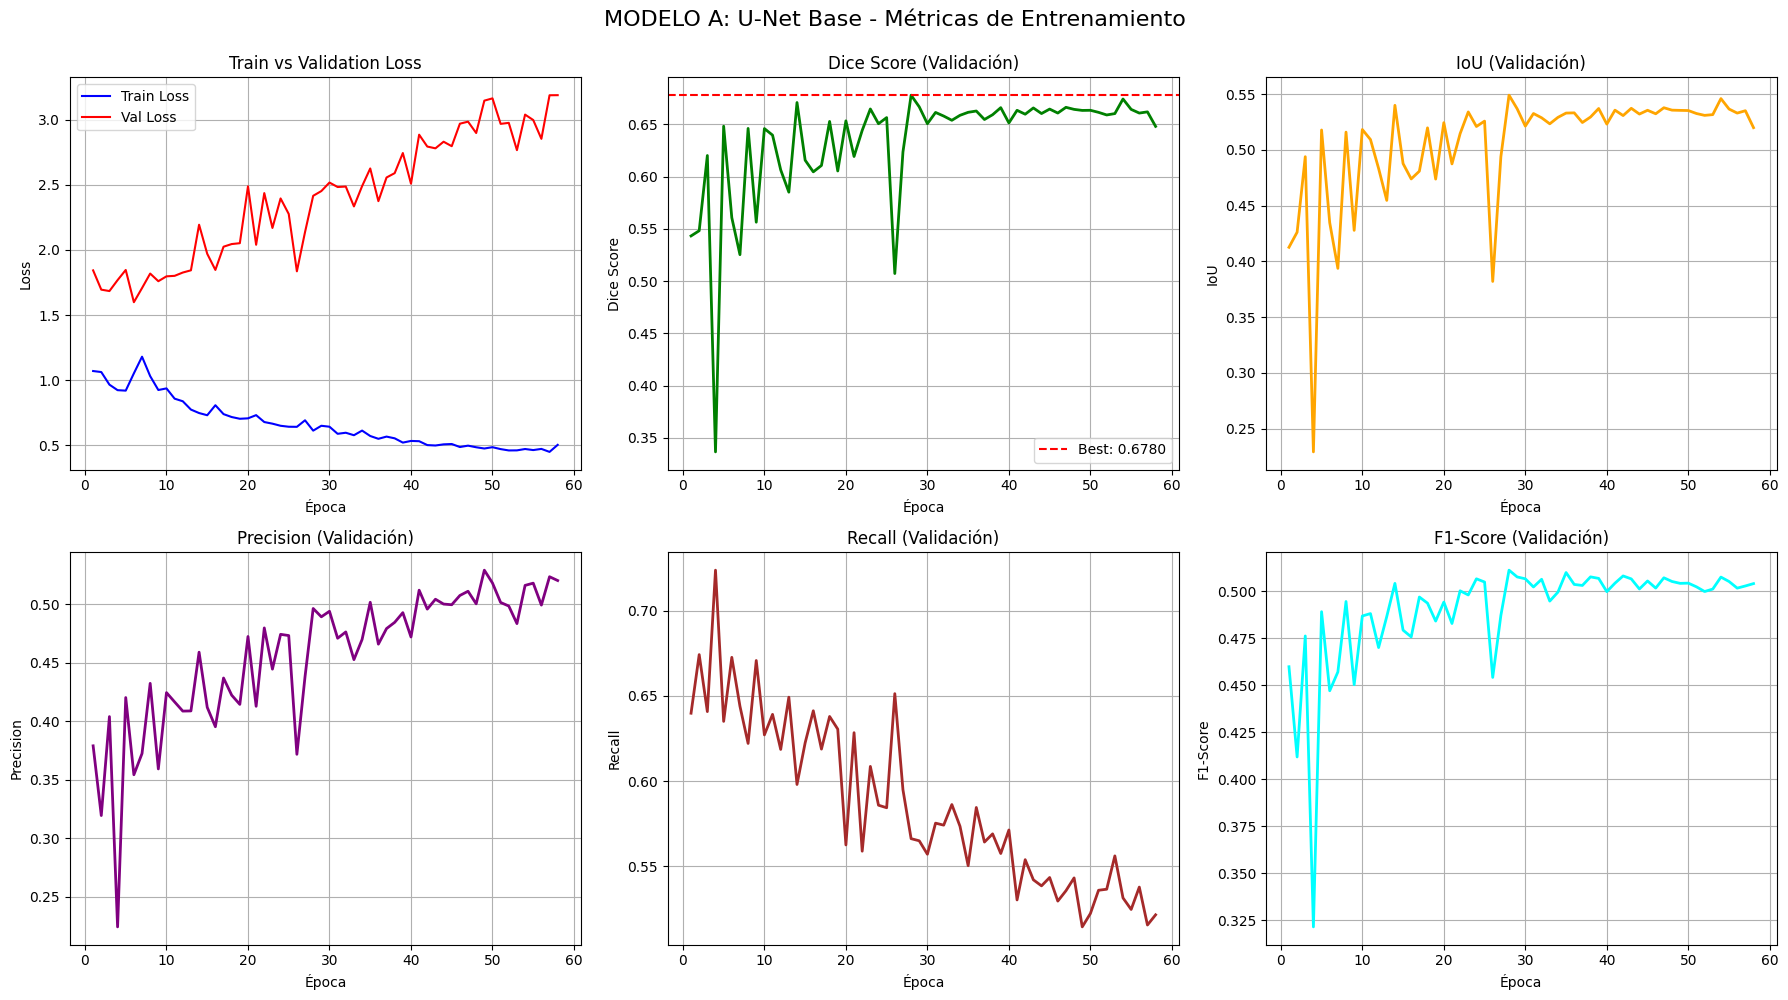

In [23]:
# Gráfico 1: Curvas de Loss
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Train vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice Score
axes[0, 1].plot(epochs_range, history['val_dice'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('Dice Score')
axes[0, 1].set_title('Dice Score (Validación)')
axes[0, 1].grid(True)
axes[0, 1].axhline(y=best_val_dice, color='r', linestyle='--', 
                   label=f'Best: {best_val_dice:.4f}')
axes[0, 1].legend()

# IoU
axes[0, 2].plot(epochs_range, history['val_iou'], 'orange', linewidth=2)
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('IoU')
axes[0, 2].set_title('IoU (Validación)')
axes[0, 2].grid(True)

# Precision
axes[1, 0].plot(epochs_range, history['val_precision'], 'purple', linewidth=2)
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision (Validación)')
axes[1, 0].grid(True)

# Recall
axes[1, 1].plot(epochs_range, history['val_recall'], 'brown', linewidth=2)
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Recall (Validación)')
axes[1, 1].grid(True)

# F1-Score
axes[1, 2].plot(epochs_range, history['val_f1'], 'cyan', linewidth=2)
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('F1-Score')
axes[1, 2].set_title('F1-Score (Validación)')
axes[1, 2].grid(True)

plt.suptitle('MODELO A: U-Net Base - Métricas de Entrenamiento', fontsize=16, y=0.995)
plt.tight_layout()
# plt.savefig('unet_base_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Gráfico de curvas guardado: unet_base_training_curves.png")

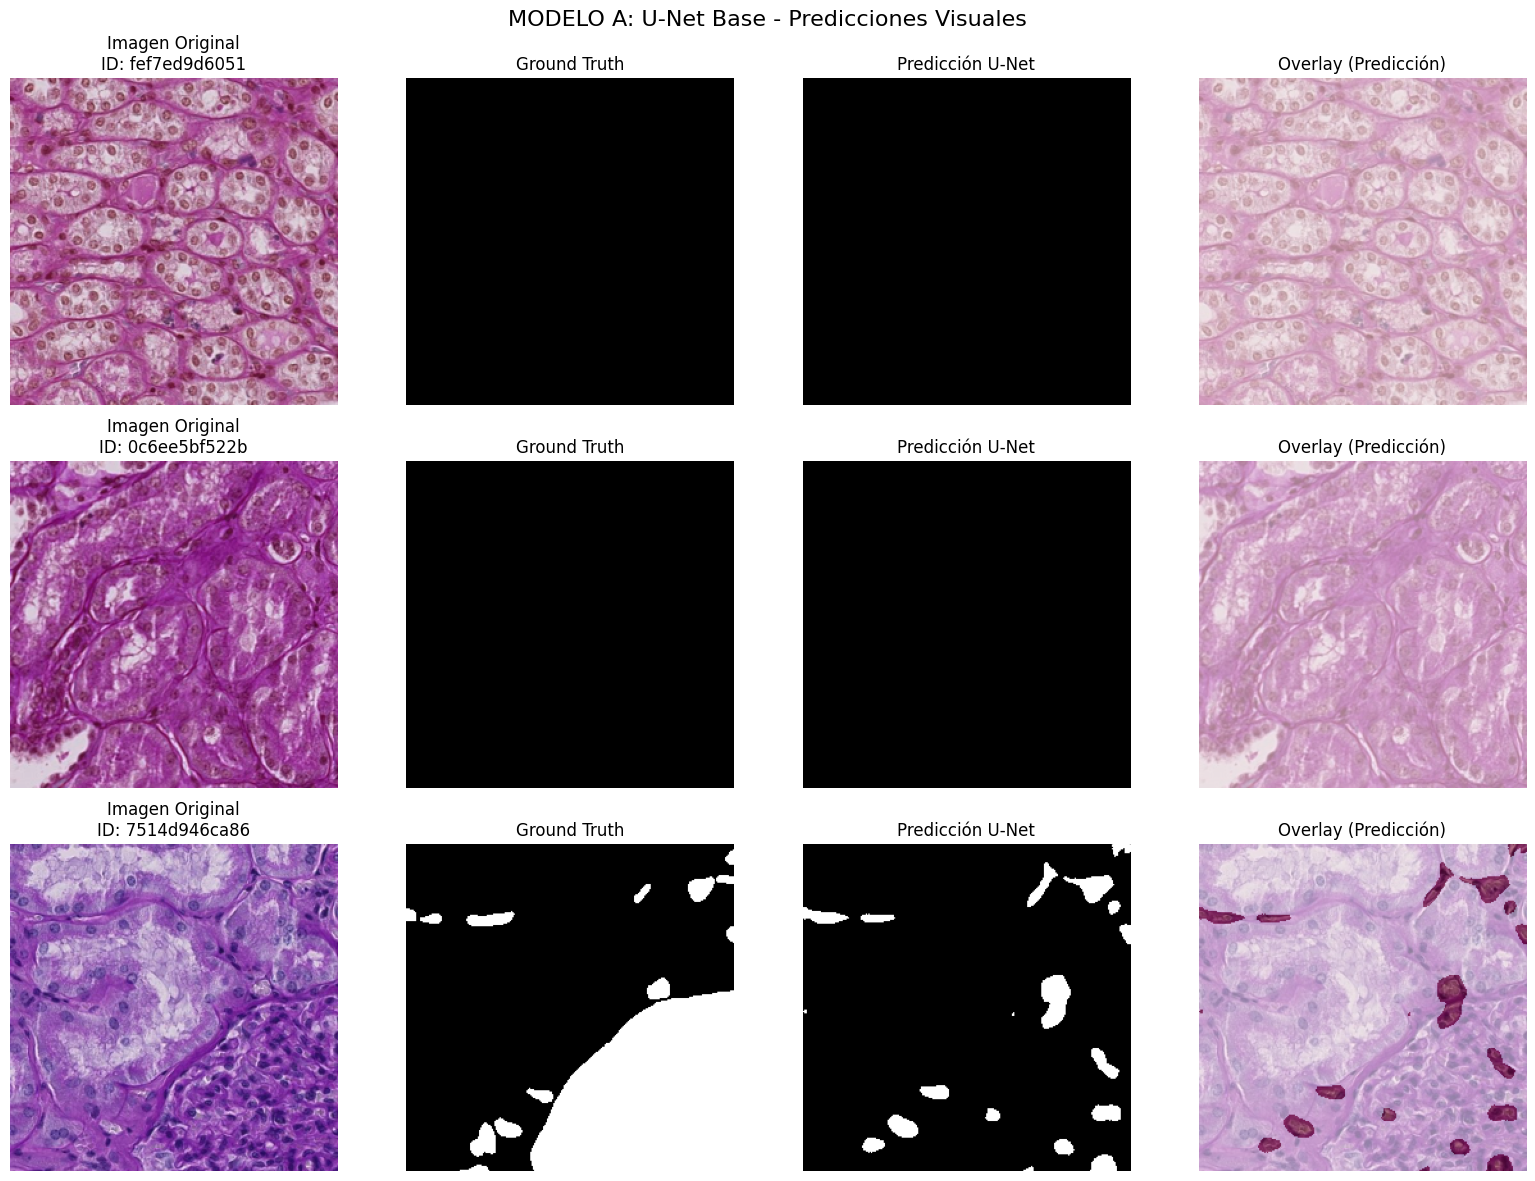

In [17]:
# Cargar mejor modelo
checkpoint = torch.load('best_unet_base.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

fig, axes = plt.subplots(3, 4, figsize=(16, 12))

with torch.no_grad():
    images, masks, tile_ids = next(iter(val_loader))
    images_gpu = images.to(device)
    outputs = model(images_gpu)
    predictions = torch.argmax(outputs, dim=1).cpu()
    
    for i in range(3):
        # Desnormalizar imagen
        img = images[i].numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        mask_gt = masks[i].numpy()
        mask_pred = predictions[i].numpy()
        
        # Imagen original
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f'Imagen Original\nID: {tile_ids[i]}')
        axes[i, 0].axis('off')
        
        # Ground truth
        axes[i, 1].imshow(mask_gt, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Predicción
        axes[i, 2].imshow(mask_pred, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title('Predicción U-Net')
        axes[i, 2].axis('off')
        
        # Overlay
        axes[i, 3].imshow(img)
        axes[i, 3].imshow(mask_pred, alpha=0.5, cmap='Reds')
        axes[i, 3].set_title('Overlay (Predicción)')
        axes[i, 3].axis('off')

plt.suptitle('MODELO A: U-Net Base - Predicciones Visuales', fontsize=16)
plt.tight_layout()
# plt.savefig('unet_base_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

# print("Gráfico de predicciones guardado: unet_base_predictions.png")